In [ ]:
from xrss.dataloader import XRayDataset, show_images_and_bboxes, SubsetDataset
from xrss.main_model import TwoStageDetector
from xrss.utils import (
    evaluate_score,
    compute_predictions_folder,
    yolo_to_submission_csv,
)

import random
from tqdm import tqdm

# Model Initialization and qualitative testing

In [2]:
yaml_file = "../xray_data/data.yaml"

train_dataset = XRayDataset(yaml_file, split="train", resize=False)
val_dataset = XRayDataset(yaml_file, split="val", resize=False)

In [3]:
model = TwoStageDetector()

model.train(train_dataset, get_features=True, stage1=True, stage2=True)

Training TwoStageDetector on 4200 images.


Extracting features: 100%|██████████| 4200/4200 [10:56<00:00,  6.39it/s]



Data collected:
  Object samples: 6211
  Background samples: 282133
  Object class distribution: Counter({np.int64(2): 1310, np.int64(1): 1115, np.int64(3): 1033, np.int64(5): 965, np.int64(4): 931, np.int64(0): 857})
STAGE 1: Training Object vs Background classifier
Accuracy: 0.918 (+/- 0.008)
STAGE 2: Training Object Class classifier
Accuracy: 0.826 (+/- 0.051)

Training complete.


Displaying sample images with ground truth bounding boxes:


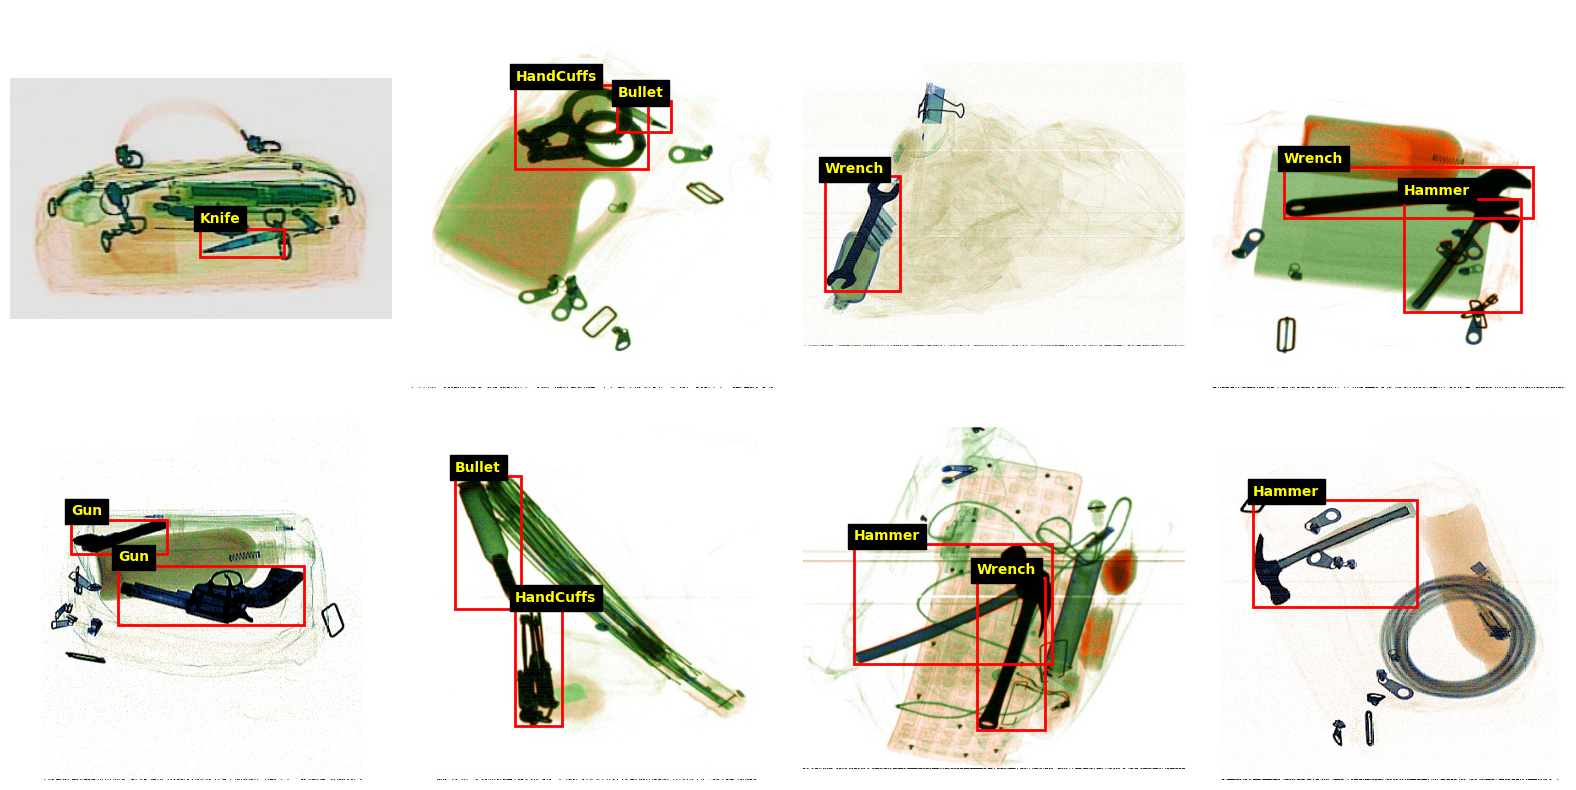

Displaying sample images with predicted bounding boxes:


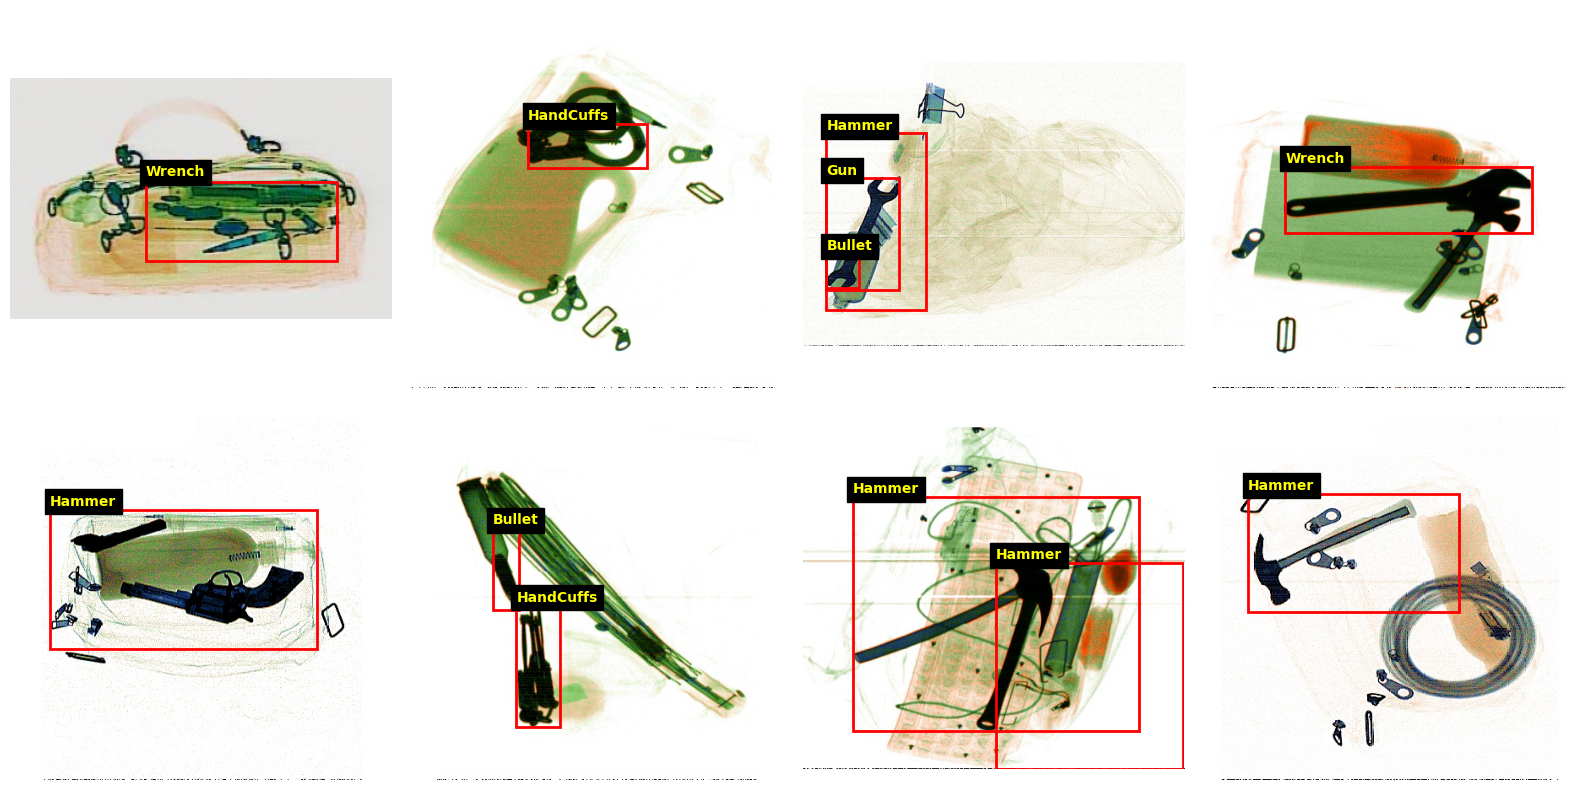

In [4]:
indexes = list(range(8))

images = [val_dataset[i][0] for i in indexes]
labels = [val_dataset[i][1] for i in indexes]

print("Displaying sample images with ground truth bounding boxes:")
show_images_and_bboxes(val_dataset, images, labels, cols=4)

preds = []
for img in images:
    boxes = model.detect(img)

    preds.append(boxes)

print("Displaying sample images with predicted bounding boxes:")
show_images_and_bboxes(val_dataset, images, preds, cols=4)

# Tuning Hyperparameters (Class Thresholds and Stage 2 Class Weights) on validation set

In [ ]:
val_subset = SubsetDataset(val_dataset, n_samples=100)

best_score_thresh = -1.0
best_thresholds = model.class_thresholds.copy()
threshold_range = (0.2, 0.95)
N_trials = 50

for i in tqdm(range(N_trials)):
    # Generate random thresholds for all 6 classes
    current_thresholds = {}
    for cls_id in range(6):
        current_thresholds[cls_id] = random.uniform(
            threshold_range[0], threshold_range[1]
        )

    # Update model thresholds directly (No training needed)
    model.class_thresholds = current_thresholds

    # Evaluate
    current_score = evaluate_score(model, val_subset)

    # Track best
    if current_score > best_score_thresh:
        best_score_thresh = current_score
        best_thresholds = current_thresholds
        print(
            f"Iter {i + 1}: New best score: {best_score_thresh:.4f} | Config: {best_thresholds}"
        )

print("\nTuning Complete")
print(f"Best Score: {best_score_thresh:.4f}")
print(f"Best Thresholds: {best_thresholds}")

In [ ]:
val_subset = SubsetDataset(val_dataset, n_samples=100)

best_score_weights = -1.0
best_weights_config = None
weight_range = (1.0, 4.0)
N_trials = 10

for i in tqdm(range(N_trials)):
    # Generate random weights
    current_weights = {}
    for cls_id in range(6):
        current_weights[cls_id] = random.uniform(weight_range[0], weight_range[1])

    print(f"\nTrial {i + 1}/5: Testing weights: {current_weights}")

    # Re initialize model with new weights
    class_thresholds = best_thresholds if best_thresholds is not None else None
    temp_model = TwoStageDetector(
        nc=6,
        stage1_threshold=0.45,
        n_estimators=200,
        stage2_class_weights=current_weights,
        class_thresholds=class_thresholds,
    )

    # Train (required for weights to take effect)
    temp_model.train(train_dataset, get_features=False, stage1=True, stage2=True)

    # Evaluate
    score = evaluate_score(temp_model, val_subset)

    if score > best_score_weights:
        best_score_weights = score
        best_weights_config = current_weights
        print(f"New Best Score: {best_score_weights:.4f}")

print("\nTuning Complete")
print(f"Final Best Score: {best_score_weights:.4f}")
print(f"Final Best Weights: {best_weights_config}")

# Evaluation on validation set

In [ ]:
model = TwoStageDetector(
    nc=6,
    stage1_threshold=0.45,
    n_estimators=200,
    class_thresholds={
        0: 0.70,
        1: 0.55,
        2: 0.40,
        3: 0.50,
        4: 0.40,
        5: 0.55,
    },
    stage2_class_weights={
        0: 1.2,
        1: 1.2,
        2: 1.0,
        3: 1.0,
        4: 1.0,
        5: 3.0,
    },
)

model.train(train_dataset, get_features=True, stage1=True, stage2=True)

Training TwoStageDetector on 4200 images.


Extracting features: 100%|██████████| 4200/4200 [10:31<00:00,  6.65it/s]



Data collected:
  Object samples: 6211
  Background samples: 282133
  Object class distribution: Counter({np.int64(2): 1310, np.int64(1): 1115, np.int64(3): 1033, np.int64(5): 965, np.int64(4): 931, np.int64(0): 857})
STAGE 1: Training Object vs Background classifier
Accuracy: 0.919 (+/- 0.014)
STAGE 2: Training Object Class classifier
Accuracy: 0.826 (+/- 0.051)

Training complete.


In [12]:
score = evaluate_score(model, val_dataset)

print(f"The final evaluation score on the full validation set is: {score:.4f}")

100%|██████████| 900/900 [19:02<00:00,  1.27s/it]

The final evaluation score on the full validation set is: 0.1723


# Compute predictions on test set and create submission file

In [ ]:
test_dataset = XRayDataset(yaml_file, split="test")
output_folder = "../predictions/TSD_test/"

In [14]:
compute_predictions_folder(
    model, test_dataset, output_folder=output_folder, replace=False
)

100%|██████████| 900/900 [18:40<00:00,  1.24s/it]


In [ ]:
yolo_to_submission_csv(output_folder, "../results/TSD_submission.csv")